# Data Extraction

In [6]:
import pandas as pd

df = pd.read_csv('/content/loans_dataset.csv')
print(f"Data Shape before filtering: {df.shape}")

Data Shape before filtering: (10000, 55)


In [7]:
#  Subset required variables
cols_keep = [
    'interest_rate', 'verified_income', 'debt_to_income', 'total_credit_utilized',
    'total_credit_limit', 'public_record_bankrupt', 'loan_purpose', 'term',
    'inquiries_last_12m', 'issue_month', 'annual_income', 'loan_amount',
    'grade', 'emp_length', 'homeownership'
]

# Create df_clean by subsetting
df_clean = df[cols_keep].copy()


# Rename column
df_clean.rename(columns={'inquiries_last_12m': 'credit_checks'}, inplace=True)

print(f"Data Shape after filtering: {df_clean.shape}")

Data Shape after filtering: (10000, 15)


In [8]:
# Stats for numerical
num_stats = df_clean.describe().loc[['count', 'mean', 'std', 'min', 'max']]
num_stats.round(2)

,interest_rate,debt_to_income,total_credit_utilized,total_credit_limit,public_record_bankrupt,term,credit_checks,annual_income,loan_amount,emp_length
count,10000.00,9976.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,9183.00
mean,12.43,19.31,51049.06,183606.23,0.12,43.27,1.96,79222.15,16361.92,5.93
std,5.00,15.00,53636.73,187632.71,0.34,11.03,2.38,64734.29,10301.96,3.70
min,5.31,0.00,0.00,0.00,0.00,36.00,0.00,0.00,1000.00,0.00
max,30.94,469.09,942456.00,3386034.00,3.00,60.00,29.00,2300000.00,40000.00,10.00


# EDA

In [9]:
# Numerical summaries
num_vars = ['interest_rate', 'annual_income', 'debt_to_income', 'loan_amount']
desc_stats = df_clean[num_vars].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
print("Descriptive Stats:\n", desc_stats)

Descriptive Stats:
         interest_rate  annual_income  debt_to_income  loan_amount
count        10000.00       10000.00         9976.00     10000.00
mean            12.43       79222.15           19.31     16361.92
median          11.98       65000.00           17.57     14500.00
std              5.00       64734.29           15.00     10301.96
min              5.31           0.00            0.00      1000.00
max             30.94     2300000.00          469.09     40000.00


In [10]:
# Categorical frequencies
cat_vars = ['grade', 'verified_income', 'homeownership']
print("Categorical frequencies\n")
for col in cat_vars:
    freq = df_clean[col].value_counts(normalize=True).mul(100).round(1)
    print(f"\n{col} (n={df_clean[col].nunique()} categories):\n{freq.to_string()}%")

Categorical frequencies


grade (n=7 categories):
grade
B    30.4
C    26.5
A    24.6
D    14.5
E     3.4
F     0.6
G     0.1%

verified_income (n=3 categories):
verified_income
Source Verified    41.2
Not Verified       35.9
Verified           22.9%

homeownership (n=3 categories):
homeownership
MORTGAGE    47.9
RENT        38.6
OWN         13.5%


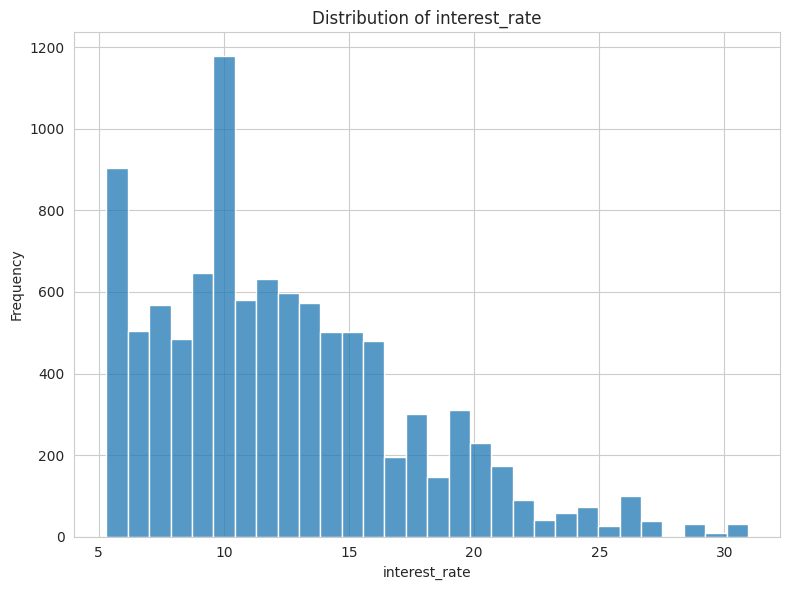

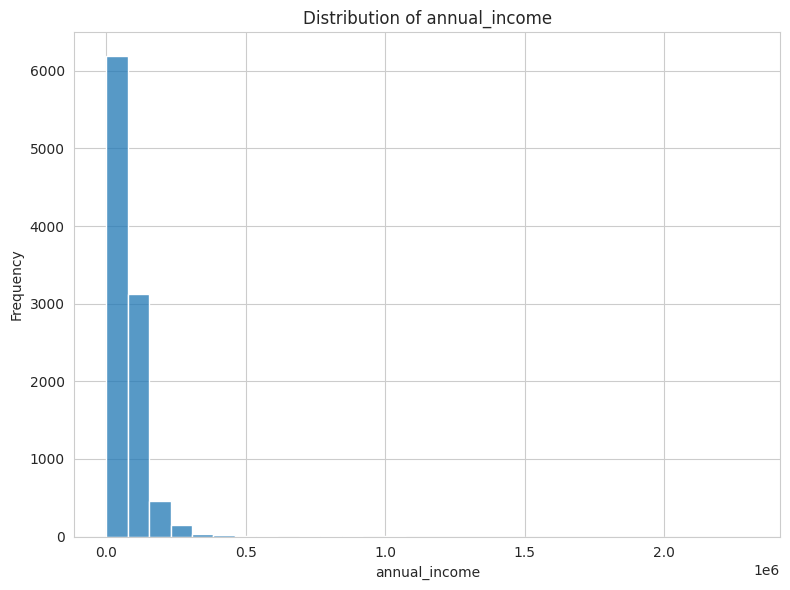

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8, 6)
sns.set_style('whitegrid')

# Histograms
for var in ['interest_rate', 'annual_income']:
    plt.figure()
    sns.histplot(df_clean[var], bins=30, kde=False)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var); plt.ylabel('Frequency')
    plt.tight_layout(); plt.show()

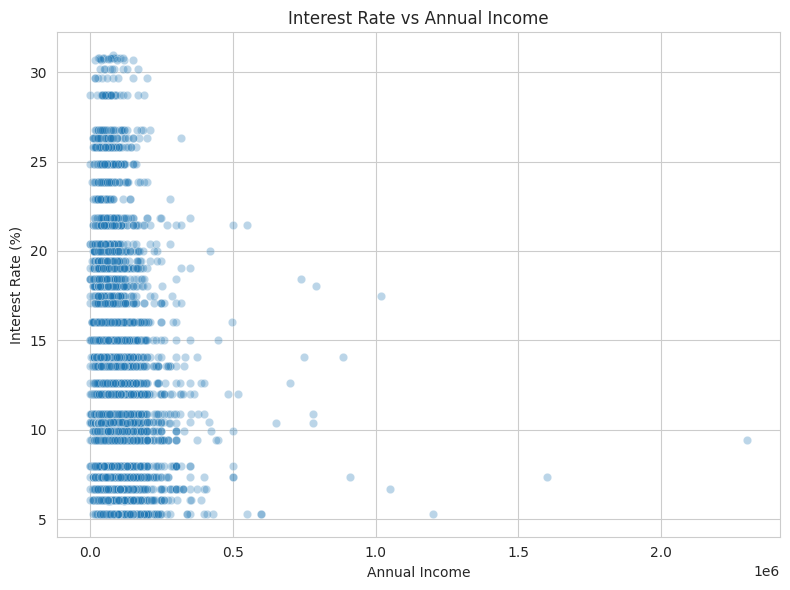

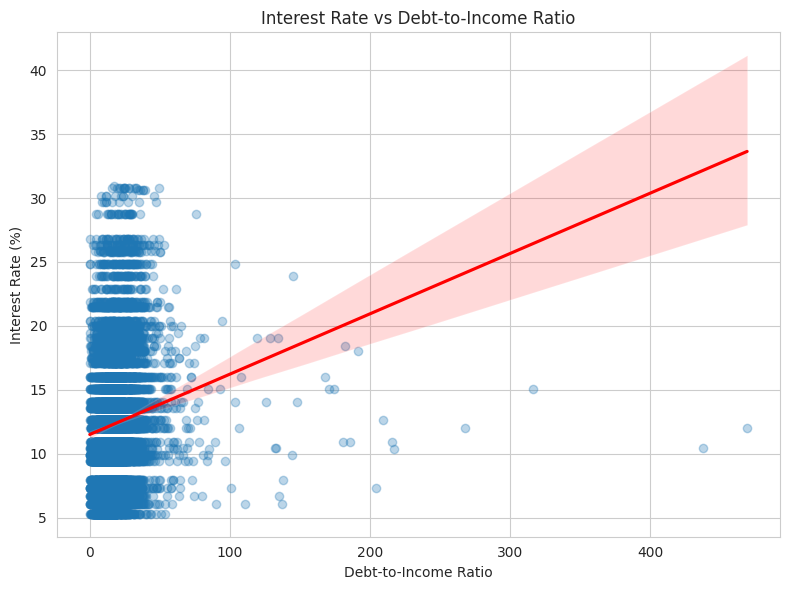

In [ ]:
#  Scatterplots
# interest_rate vs annual_income
plt.figure()
sns.scatterplot(x='annual_income', y='interest_rate', data=df, alpha=0.3)
plt.title('Interest Rate vs Annual Income'); plt.xlabel('Annual Income'); plt.ylabel('Interest Rate (%)')
plt.tight_layout(); plt.show()

# interest_rate vs (debt_to_income + regression line)
plt.figure()
sns.regplot(x='debt_to_income', y='interest_rate', data=df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Interest Rate vs Debt-to-Income Ratio')
plt.xlabel('Debt-to-Income Ratio'); plt.ylabel('Interest Rate (%)')
plt.tight_layout(); plt.show()

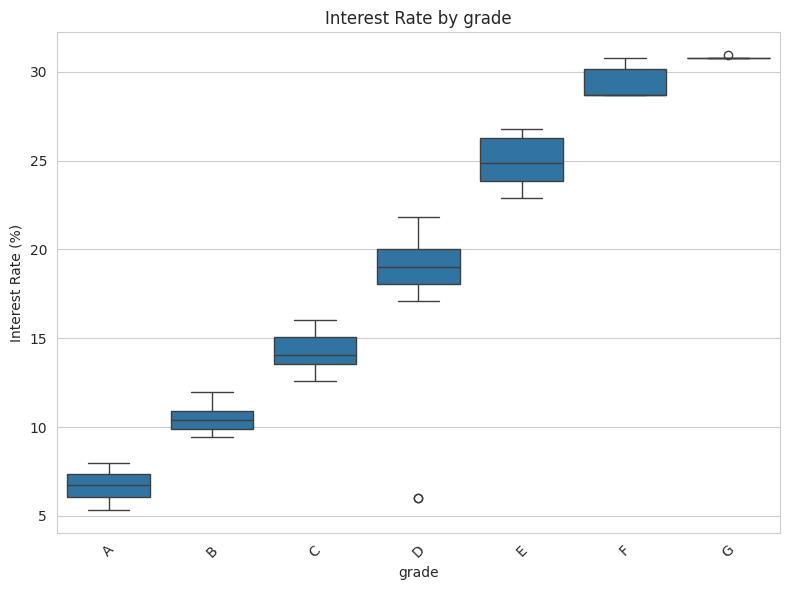

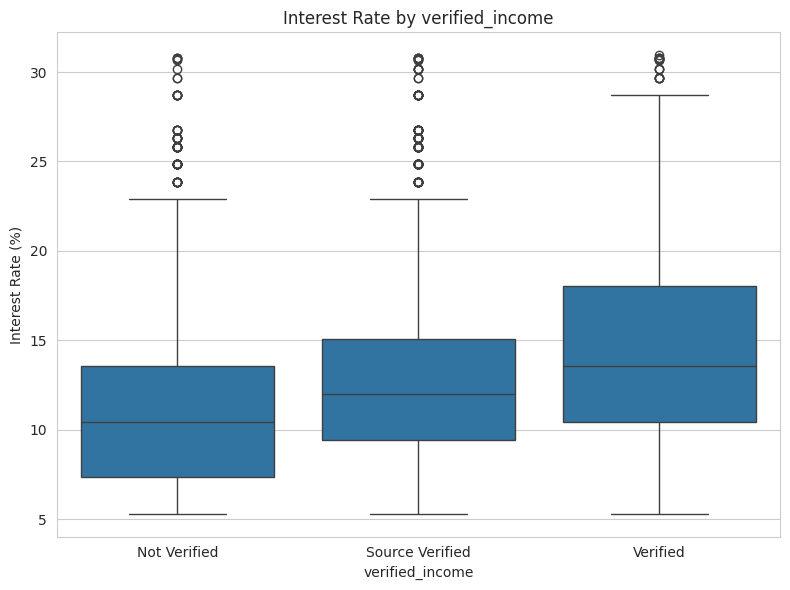

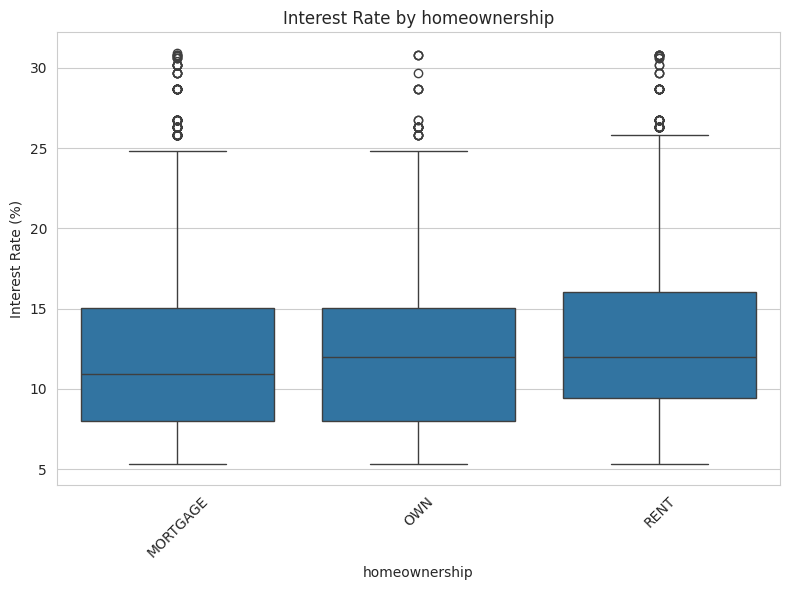

In [ ]:
# Boxplots by categorical variables
for col in ['grade', 'verified_income', 'homeownership']:
    plt.figure()
    sns.boxplot(x=col, y='interest_rate', data=df_clean, order=sorted(df_clean[col].unique()))
    plt.title(f'Interest Rate by {col}')
    plt.xlabel(col); plt.ylabel('Interest Rate (%)')
    plt.xticks(rotation=45) if col in ['grade','homeownership'] else None
    plt.tight_layout(); plt.show()

Feature Engineering

In [ ]:
# credit Utilization Ratio (handle div-by-zero)
df_clean['credit_util'] = np.where(
    df_clean['total_credit_limit'] == 0,
    0,
    df_clean['total_credit_utilized'] / df_clean['total_credit_limit']
)

# Bankruptcy Dummy
df_clean['bankruptcy_dummy'] = (df_clean['public_record_bankrupt'] >= 1).astype(int)

for var in ['credit_util', 'bankruptcy_dummy']:
    mean_val = df_clean[var].mean()
    pct_nonzero = (df_clean[var] != 0).mean() * 100
    print(f"{var}: Mean = {mean_val:.4f}, % Non-zero = {pct_nonzero:.2f}%")

credit_util: Mean = 0.4031, % Non-zero = 99.72%
bankruptcy_dummy: Mean = 0.1215, % Non-zero = 12.15%


# Regression Analysis

In [ ]:
import statsmodels.api as sm

# variables needed for models
model_vars = [
    'interest_rate', 'debt_to_income', 'credit_util', 'bankruptcy_dummy',
    'annual_income', 'loan_amount', 'term', 'grade', 'emp_length',
    'homeownership', 'loan_purpose', 'credit_checks', 'verified_income'
]
df_mod = df_clean[model_vars].dropna().reset_index(drop=True)

# Verify clean exog/endog
assert not df_mod.isnull().any().any(), "NaNs still present in modeling data"
y = df_mod['interest_rate']
print(f"modeling sample size after dropping NaNs: {len(df_mod)}")

modeling sample size after dropping NaNs: 9182


In [ ]:
# Outlier Detection (IQR Method)
from scipy import stats

# Numerical variables to check
num_vars = ['interest_rate', 'annual_income', 'debt_to_income', 'loan_amount', 'credit_util']

print("Outliers (IQR Method):\n")
for var in num_vars:
    Q1 = df_mod[var].quantile(0.25)
    Q3 = df_mod[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_mod[(df_mod[var] < lower_bound) | (df_mod[var] > upper_bound)]
    outlier_pct = len(outliers) / len(df_mod) * 100

    print(f"\n{var}:")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers: {len(outliers)} ({outlier_pct:.2f}% of observations)")
    if len(outliers) > 0:
        print(f"  Min: {outliers[var].min():.2f}, Max: {outliers[var].max():.2f}")


Outliers (IQR Method):


interest_rate:
  Bounds: [1.00, 23.48]
  Outliers: 336 (3.66% of observations)
  Min: 23.87, Max: 30.94

annual_income:
  Bounds: [-27142.38, 174576.62]
  Outliers: 497 (5.41% of observations)
  Min: 175000.00, Max: 2300000.00

debt_to_income:
  Bounds: [-9.61, 45.38]
  Outliers: 184 (2.00% of observations)
  Min: 45.47, Max: 469.09

loan_amount:
  Bounds: [-14750.00, 47250.00]
  Outliers: 0 (0.00% of observations)

credit_util:
  Bounds: [-0.49, 1.27]
  Outliers: 20 (0.22% of observations)
  Min: 1.31, Max: 1.84


## Model 1

In [ ]:
# interest_rate = β0 + β1*debt_to_income + ε
X1 = sm.add_constant(df_mod['debt_to_income'])
model1 = sm.OLS(y, X1).fit()
print("Model 1 Summary:\n", model1.summary().tables[1])

Model 1 Summary:
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             11.4097      0.086    132.272      0.000      11.241      11.579
debt_to_income     0.0524      0.004     14.404      0.000       0.045       0.060


## Model 2

In [ ]:
# interest_rate = β0 + β1*bankruptcy_dummy + ε
X2 = sm.add_constant(df_mod['bankruptcy_dummy'])
model2 = sm.OLS(y, X2).fit()
print("Model 2 Summary:\n", model2.summary().tables[1])

Model 2 Summary:
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               12.3164      0.055    221.971      0.000      12.208      12.425
bankruptcy_dummy     0.7627      0.163      4.683      0.000       0.443       1.082


## Model 3

In [ ]:
df_mod = pd.get_dummies(df_mod, columns=['verified_income'], drop_first=True, dtype=float)
dummy_cols_v = [c for c in df_mod.columns if c.startswith('verified_income_')]

X3 = sm.add_constant(df_mod[dummy_cols_v])
model3 = sm.OLS(y, X3).fit()

print(f"Predicted avg interest_rate for reference: {model3.params['const']:.2f}%\n")
print(model3.summary())

Predicted avg interest_rate for reference: 11.02%

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     322.1
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          6.35e-136
Time:                        17:50:28   Log-Likelihood:                -27503.
No. Observations:                9182   AIC:                         5.501e+04
Df Residuals:                    9179   BIC:                         5.503e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

## Model 4

In [ ]:
# interest_rate = β0 + β1*debt_to_income + β2*credit_util + β3*bankruptcy_dummy + ε
X4 = sm.add_constant(df_mod[['debt_to_income', 'credit_util', 'bankruptcy_dummy']])
model4 = sm.OLS(y, X4).fit()

print(f"B_debt_to_income changed: M1={model1.params['debt_to_income']:.4f} -> M4={model4.params['debt_to_income']:.4f}\n")

print(model4.summary())

B_debt_to_income changed: M1=0.0524 -> M4=0.0410

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     267.7
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          1.38e-166
Time:                        17:50:31   Log-Likelihood:                -27429.
No. Observations:                9182   AIC:                         5.487e+04
Df Residuals:                    9178   BIC:                         5.489e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

## Model 5

In [ ]:
# Encode all remaining categoricals
cat_vars = ['grade', 'homeownership', 'term', 'emp_length', 'loan_purpose']
df_mod5 = df_mod.copy()
df_mod5 = pd.get_dummies(df_mod5, columns=cat_vars, drop_first=True, dtype=float)

# Identify all dummy columns created
dummy_cols_m5 = [c for c in df_mod5.columns if any(cv in c for cv in cat_vars)]
num_cols_m5 = ['debt_to_income', 'credit_util', 'bankruptcy_dummy',
               'annual_income', 'loan_amount', 'credit_checks']
X5 = sm.add_constant(df_mod5[num_cols_m5 + dummy_cols_m5])

model5 = sm.OLS(y, X5).fit()

# State reference categories
ref_grade = 'A'
ref_home = sorted(df_mod['homeownership'].unique())[0]
print(f"Reference categories dropped: grade='{ref_grade}', homeownership='{ref_home}'\n")
print(f"Residuals (1st 5 rows):\n{model5.resid.head().to_string()}")

Reference categories dropped: grade='A', homeownership='MORTGAGE'

Residuals (1st 5 rows):
0   -0.298464
1   -1.407966
2   -2.111968
3    0.038474
4   -0.328811


In [ ]:
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     5042.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:05:51   Log-Likelihood:                -13870.
No. Observations:                9182   AIC:                         2.781e+04
Df Residuals:                    9145   BIC:                         2.808e+04
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     